# Experimento 9 — Corrección de tipeo en el preprocesamiento

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento7.ipynb` y `experimento8.ipynb`. La sección 1 repite de forma resumida la
configuración común (misma semilla, mismo split y mismos folds). Los experimentos anteriores **no se vuelven a
ejecutar**: sus métricas se registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 9 — Corrección de tipeo

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de experimentos anteriores tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 5, "descripcion": "Un nivel: detector de opinión (sin conector) + TF-IDF por partes + LinearSVC",
     "acc_cv": 0.9022, "std_cv": 0.0080, "acc_test": 0.9021, "envio": "submission_05.csv", "kaggle_publico": None},
    {"experimento": 7, "descripcion": "Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1)",
     "acc_cv": 0.9071, "std_cv": 0.0091, "acc_test": 0.9046, "envio": "submission_07.csv", "kaggle_publico": 0.91},
    {"experimento": 8, "descripcion": "Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",
     "acc_cv": 0.9048, "std_cv": 0.0083, "acc_test": 0.9096, "envio": "submission_08.csv", "kaggle_publico": None},
]:
    resultados.append(fila)

# Accuracy por fold (mismos folds) tomadas de sus notebooks
ACC_FOLDS_E5 = np.array([0.9036, 0.9047, 0.9052, 0.9104, 0.8870])   # experimento5.ipynb, sección 2.2 (variante A)
ACC_FOLDS_E7 = np.array([0.9130, 0.9010, 0.9161, 0.9130, 0.8922])   # experimento7.ipynb, sección 2.4
ACC_FOLDS_E8 = np.array([0.9042, 0.8990, 0.9167, 0.9109, 0.8932])   # experimento8.ipynb, sección 2.3

ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 7", "escenario": "Original", "accuracy": 0.9046},
    {"modelo": "Exp. 7", "escenario": "Oraciones desordenadas", "accuracy": 0.7458},
    {"modelo": "Exp. 7", "escenario": "Última oración al inicio", "accuracy": 0.6008},
    {"modelo": "Exp. 8", "escenario": "Original", "accuracy": 0.9096},
    {"modelo": "Exp. 8", "escenario": "Oraciones desordenadas", "accuracy": 0.7621},
    {"modelo": "Exp. 8", "escenario": "Última oración al inicio", "accuracy": 0.6467},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,5,Un nivel: detector de opinión (sin conector) + TF-IDF por partes + LinearSVC,NaN,NaN,0.9022,0.0080,NaN,0.9021,NaN,submission_05.csv,NaN
2,7,Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1),NaN,NaN,0.9071,0.0091,NaN,0.9046,NaN,submission_07.csv,0.91
3,8,"Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",NaN,NaN,0.9048,0.0083,NaN,0.9096,NaN,submission_08.csv,NaN


## 2. Experimento 9 — Corrección de tipeo

**Motivación:** los experimentos 5 a 8 mostraron que cambiar o combinar clasificadores ya solo mueve la accuracy en
décimas. Lo que queda por debajo del techo estimado (≈ 0,937) son sobre todo errores al **leer la polaridad** de
oraciones concretas. Una causa visible es el ruido del texto: en la exploración (`experimento1.ipynb`, sección 1.6)
el **40 % del vocabulario** aparece una sola vez, y muchas de esas palabras son **errores de tipeo** de palabras
frecuentes, incluidas palabras de opinión (`reslto`, `espectacullar`, `recomiedo`). Una palabra mal escrita no
coincide con ninguna palabra que el modelo conozca, y su información se pierde.

**Idea:** agregar un paso de **preprocesamiento** que corrija los errores de tipeo antes de todo lo demás. No agrega
modelos: es una técnica de procesamiento de texto (distancia de edición), dentro de lo que permite el enunciado.

**Proceso:**
1. Definir el corrector y verificar sus correcciones.
2. Medir su efecto en el modelo de un nivel (experimento 5), que es rápido de evaluar.
3. Agregarlo al modelo de dos niveles y comparar los dos combinadores de los experimentos 7 (SVM RBF) y 8 (LR +
   interacciones), fold por fold, contra sus versiones sin corrector.
4. Modelo final, test, robustez y envío.

### 2.1 Definiciones

Las mismas funciones y el mismo transformador `PartesE5` de `experimento5.ipynb` (sección 2.1).

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

### 2.2 Corrector de tipeo

Funcionamiento (`CorrectorTipeo`):
1. En `fit`, se cuentan las palabras de los textos de **entrenamiento** (sin usar etiquetas). Se consideran
   **frecuentes** las que aparecen 15 veces o más, y **raras** las que aparecen 1 o 2 veces.
2. Para cada palabra rara (de 4 letras o más) se generan todas las palabras a **distancia de edición 1**: borrar,
   insertar o cambiar una letra, o intercambiar dos letras vecinas. Si alguna de ellas es frecuente, la palabra rara
   se reemplaza por la candidata **más frecuente**.
3. En `transform`, se aplica ese diccionario. Las palabras que no aparecieron en entrenamiento (reseñas de validación
   o de eval) se corrigen con el mismo criterio, comparando solo contra el vocabulario frecuente del entrenamiento.

**¿Es leakage?** No: el corrector no usa etiquetas, y su vocabulario se construye solo con los textos de
entrenamiento de cada fold (va dentro del entrenamiento del nivel 1, incluido el cross-fitting). Las reseñas de
validación, test o eval nunca aportan palabras al vocabulario.

In [7]:
from collections import Counter

LETRAS = "abcdefghijklmnopqrstuvwxyzñ"
PATRON_PALABRA = re.compile(r"[a-zñ]+")


def ediciones_distancia_1(palabra):
    """Todas las cadenas a distancia de edición 1: borrado, transposición, sustitución e inserción."""
    cortes = [(palabra[:i], palabra[i:]) for i in range(len(palabra) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transposiciones = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituciones = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    inserciones = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transposiciones + sustituciones + inserciones)


class CorrectorTipeo(BaseEstimator, TransformerMixin):
    """Reemplaza palabras raras por la palabra frecuente más parecida (distancia de edición 1)."""

    def __init__(self, max_rara=2, min_frecuente=15, min_largo=4):
        self.max_rara = max_rara
        self.min_frecuente = min_frecuente
        self.min_largo = min_largo

    def fit(self, X, y=None):
        self.frecuencias_ = Counter(p for texto in X for p in PATRON_PALABRA.findall(texto))
        self.frecuentes_ = {p: f for p, f in self.frecuencias_.items() if f >= self.min_frecuente}
        self.correcciones_ = {}
        for palabra, f in self.frecuencias_.items():
            if f <= self.max_rara and len(palabra) >= self.min_largo:
                candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
                if candidatas:
                    self.correcciones_[palabra] = max(candidatas, key=self.frecuentes_.get)
        return self

    def _corregir(self, palabra):
        if palabra in self.correcciones_:
            return self.correcciones_[palabra]
        if palabra not in self.frecuencias_ and len(palabra) >= self.min_largo:   # palabra nunca vista en train
            candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
            if candidatas:
                return max(candidatas, key=self.frecuentes_.get)
        return palabra

    def transform(self, X):
        return [PATRON_PALABRA.sub(lambda m: self._corregir(m.group()), texto) for texto in X]


corrector_demo = CorrectorTipeo().fit(X_train)
print(f"Palabras raras de X_train corregidas: {len(corrector_demo.correcciones_)}")
pd.DataFrame(list(corrector_demo.correcciones_.items())[:30], columns=["palabra original", "corrección"]).T

Palabras raras de X_train corregidas: 933


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
palabra original,reslto,oficiina,epmaque,naad,revisare,articulos,negros,trres,venai,diaario,...,pura,allegra,espectacullar,pediddos,normallmente,seegun,pedia,sellad,azzul,fabriante
corrección,resulto,oficina,empaque,nada,revisar,articulo,negro,tres,venia,diario,...,para,alegra,espectacular,pedidos,normalmente,segun,pedi,sellada,azul,fabricante


In [8]:
# Efecto sobre el vocabulario y ejemplo de una reseña corregida
antes = Counter(p for t in X_train for p in PATRON_PALABRA.findall(t))
despues = Counter(p for t in corrector_demo.transform(X_train) for p in PATRON_PALABRA.findall(t))
print(f"Palabras distintas: {len(antes):,} -> {len(despues):,}")
print(f"Palabras que aparecen una sola vez: {sum(f == 1 for f in antes.values()):,} -> "
      f"{sum(f == 1 for f in despues.values()):,}")

ejemplo = next(t for t in X_train if any(p in corrector_demo.correcciones_ for p in PATRON_PALABRA.findall(t)))
print("\nANTES  :", ejemplo)
print("DESPUÉS:", corrector_demo.transform([ejemplo])[0])

Palabras distintas: 4,958 -> 4,025
Palabras que aparecen una sola vez: 1,990 -> 1,216

ANTES  : hace unos dias, lo uso a diario. la verdad, el material me reslto optimo la verdad. con todo, el material se ve defectuoso la verdad.
DESPUÉS: hace unos dias, lo uso a diario. la verdad, el material me resulto optimo la verdad. con todo, el material se ve defectuoso la verdad.


**Lectura**

- El corrector encuentra una corrección para **933** palabras raras de `X_train`, en su mayoría errores de tipeo
  reales: `reslto → resulto`, `espectacullar → espectacular`, `epmaque → empaque`, `fabriante → fabricante`.
- Comete algunos errores (`pura → para`, `revisare → revisar`, `articulos → articulo`): a distancia 1, a veces la
  palabra frecuente más cercana no es la correcta. Son pocos y casi siempre en palabras sin carga de sentimiento.
- El vocabulario baja de 4.958 a 4.025 palabras distintas, y las palabras que aparecen una sola vez de 1.990 a 1.216
  (−39 %): el texto queda bastante más limpio.

### 2.3 Efecto en el modelo de un nivel

Primero se mide el corrector sobre el modelo del experimento 5 (detector de opinión + TF-IDF por partes +
LinearSVC), que se evalúa en pocos minutos. La única diferencia es el corrector como primer paso del pipeline.

In [9]:
pipe_e5_corrector = Pipeline([("corrector", CorrectorTipeo())] + pipeline_e5(quitar=True).steps)
acc_e5_corr = cross_val_score(pipe_e5_corrector, X_train, y_train, cv=skf, n_jobs=-1)

pd.DataFrame({"exp. 5 (sin corrector)": ACC_FOLDS_E5, "exp. 5 + corrector": acc_e5_corr},
             index=[f"fold {k}" for k in range(1, 6)]).T.assign(
    media=lambda d: d.mean(axis=1), std=lambda d: d.iloc[:, :5].std(axis=1, ddof=0)).round(4)

,fold 1,fold 2,fold 3,fold 4,fold 5,media,std
exp. 5 (sin corrector),0.9036,0.9047,0.9052,0.9104,0.8870,0.9022,0.0079
exp. 5 + corrector,0.9062,0.9062,0.9062,0.9104,0.8885,0.9035,0.0077


### 2.4 Nivel 1 con corrector y caché de features

Mismo nivel 1 de los experimentos 7 y 8 (detector, TF-IDF por partes, LinearSVC, LR y ComplementNB como modelos
base, modelo de polaridad de oraciones), con el corrector como **primer paso**: `fit_nivel1` ajusta el corrector con
los textos de entrenamiento y corrige todo antes de seguir; `features_nivel1` aplica ese mismo corrector a las
reseñas que se van a puntuar. Las features de nivel 2 se calculan con cross-fitting y se guardan en caché, como en
el experimento 7 (≈ 15 minutos).

In [10]:
import time

from joblib import Parallel, delayed
from sklearn.base import ClassifierMixin
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC

NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}
COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


def fit_nivel1(X, y):
    """Corrector + detector + TF-IDF por partes; tres modelos base y un modelo de polaridad de oraciones."""
    corrector = CorrectorTipeo().fit(X)
    X = corrector.transform(X)
    partes = PartesE5(quitar=True).fit(X, y)
    D = partes.transform(X)
    tfidf = ColumnTransformer([(c, tfidf_palabras(), c) for c in COLUMNAS_PARTES]).fit(D)
    M = tfidf.transform(D)
    bases = {
        "svc": LinearSVC(C=0.2, max_iter=5000, random_state=SEED).fit(M, y),
        "lr": LogisticRegression(C=1, max_iter=4000, random_state=SEED).fit(M, y),
        "cnb": ComplementNB(alpha=0.3).fit(M, y),
    }
    y = np.asarray(y)
    es_np = y != "neutral"
    ultimas = [quitar_conector(partes.opiniones(t)[-1]) for t, m in zip(X, es_np) if m]
    polaridad = Pipeline([
        ("tfidf", tfidf_palabras()),
        ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
    ]).fit(ultimas, y[es_np])
    return corrector, partes, tfidf, bases, polaridad


def features_nivel1(X, nivel1):
    """Features de nivel 2 por bloques: puntajes de cada modelo base + 14 features estructurales."""
    corrector, partes, tfidf, bases, polaridad = nivel1
    X = corrector.transform(X)
    M = tfidf.transform(partes.transform(X))
    bloques = {
        "svc": bases["svc"].decision_function(M),
        "lr": bases["lr"].predict_log_proba(M),
        "cnb": bases["cnb"].predict_log_proba(M),
    }
    estructura = []
    for texto in X:
        ops = partes.opiniones(texto)
        pols = list(polaridad.decision_function([quitar_conector(o) for o in ops[-3:]]))
        pols = [0.0] * (3 - len(pols)) + pols
        g_ult = grupo_conector(ops[-1])
        g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
        fila = pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])), float(pols[-1] * pols[-2] < 0)]
        fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
        estructura.append(fila)
    bloques["estructura"] = np.array(estructura)
    return bloques


def features_cross_fitting(X, y, k=5):
    """Features de nivel 2 para X calculadas con modelos de nivel 1 que no vieron cada reseña."""
    X = pd.Series(list(X))
    y = np.asarray(y)
    F = None
    for idx_tr, idx_va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y):
        bloques = features_nivel1(list(X.iloc[idx_va]), fit_nivel1(list(X.iloc[idx_tr]), y[idx_tr]))
        if F is None:
            F = {b: np.zeros((len(X), v.shape[1])) for b, v in bloques.items()}
        for b, v in bloques.items():
            F[b][idx_va] = v
    return F


def matriz(bloques, bases):
    return np.hstack([bloques[b] for b in bases + ["estructura"]])


def _fold_externo(idx_tr, idx_va):
    X_tr, y_tr = X_train.iloc[idx_tr], y_train.iloc[idx_tr]
    F_tr = features_cross_fitting(X_tr, y_tr)
    F_va = features_nivel1(list(X_train.iloc[idx_va]), fit_nivel1(list(X_tr), y_tr.to_numpy()))
    return F_tr, F_va, y_tr.to_numpy(), y_train.iloc[idx_va].to_numpy()


inicio = time.time()
CACHE = Parallel(n_jobs=5)(delayed(_fold_externo)(tr, va) for tr, va in skf.split(X_train, y_train))
print(f"Features de nivel 2 calculadas para los 5 folds en {(time.time() - inicio) / 60:.1f} min")

Features de nivel 2 calculadas para los 5 folds en 2.6 min


### 2.5 Combinadores con corrector

Los dos combinadores finalistas, con exactamente los mismos hiperparámetros de los experimentos 7 y 8, ahora sobre
las features calculadas con el corrector. Se comparan fold por fold con sus versiones sin corrector.

In [11]:
def evaluar_cache(fabrica, bases=("svc",)):
    accs = []
    for F_tr, F_va, y_tr, y_va in CACHE:
        modelo = fabrica().fit(matriz(F_tr, list(bases)), y_tr)
        accs.append(accuracy_score(y_va, modelo.predict(matriz(F_va, list(bases)))))
    return np.array(accs)


def svm_rbf():
    return Pipeline([("escala", StandardScaler()), ("clf", SVC(C=1, kernel="rbf", random_state=SEED))])


def lr_interacciones(C=0.03):
    return Pipeline([
        ("escala", StandardScaler()),
        ("interacciones", PolynomialFeatures(degree=2, include_bias=False)),
        ("escala2", StandardScaler()),
        ("clf", LogisticRegression(C=C, max_iter=5000, random_state=SEED)),
    ])


acc = {
    "[ref. exp. 7] SVM RBF, sin corrector": ACC_FOLDS_E7,
    "SVM RBF + corrector": evaluar_cache(svm_rbf),
    "[ref. exp. 8] LR + interacciones, sin corrector": ACC_FOLDS_E8,
    "LR + interacciones + corrector": evaluar_cache(lr_interacciones),
}
tabla = pd.DataFrame(acc, index=[f"fold {k}" for k in range(1, 6)]).T
tabla["media"] = tabla.mean(axis=1)
tabla["std"] = tabla.iloc[:, :5].std(axis=1, ddof=0)
tabla["folds que gana a su versión sin corrector"] = [
    "", int((acc["SVM RBF + corrector"] > ACC_FOLDS_E7).sum()),
    "", int((acc["LR + interacciones + corrector"] > ACC_FOLDS_E8).sum()),
]
tabla.round(4)

,fold 1,fold 2,fold 3,fold 4,fold 5,media,std,folds que gana a su versión sin corrector
"[ref. exp. 7] SVM RBF, sin corrector",0.9130,0.9010,0.9161,0.9130,0.8922,0.9071,0.0091,
SVM RBF + corrector,0.9115,0.9016,0.9161,0.9109,0.8922,0.9065,0.0086,2
"[ref. exp. 8] LR + interacciones, sin corrector",0.9042,0.8990,0.9167,0.9109,0.8932,0.9048,0.0083,
LR + interacciones + corrector,0.9031,0.9010,0.9172,0.9104,0.8927,0.9049,0.0083,2


**Lectura**

- En el **modelo de un nivel** (sección 2.3), el corrector mejora de forma pequeña pero consistente: +0,13
  puntos, gana en 4 de 5 folds y empata en el otro.
- En el **modelo de dos niveles**, el efecto desaparece: −0,06 puntos con el SVM RBF y +0,01 con la regresión logística
  con interacciones, cada uno ganando solo 2 de 5 folds. Es un **empate**.
- Una explicación plausible: el modelo de dos niveles ya compensa buena parte del ruido de tipeo. El modelo de
  polaridad, las features de estructura y el combinador aportan varias señales sobre la misma reseña, y una palabra
  mal escrita en una oración pesa menos cuando la decisión no depende solo del TF-IDF. La información que el
  corrector recupera ya estaba, en gran parte, disponible por otras vías.

### 2.6 Modelo del experimento 9

Se usa el combinador con mejor accuracy de CV de la tabla anterior. La clase `DosNivelesV2` es la misma de los
experimentos 7 y 8 (cross-fitting en `fit`, nivel 1 reentrenado con todos los datos para predecir); el corrector va
dentro de `fit_nivel1`.

In [12]:
class DosNivelesV2(BaseEstimator, ClassifierMixin):
    """Stacking de dos niveles con modelos base y combinador configurables."""

    def __init__(self, bases=("svc",), nivel2=None):
        self.bases = bases
        self.nivel2 = nivel2

    def fit(self, X, y):
        X = pd.Series(list(X))
        y = np.asarray(y)
        F = features_cross_fitting(X, y)
        self.nivel1_ = fit_nivel1(list(X), y)
        self.nivel2_ = clone(self.nivel2).fit(matriz(F, list(self.bases)), y)
        self.classes_ = self.nivel2_.classes_
        return self

    def predict(self, X):
        return self.nivel2_.predict(matriz(features_nivel1(list(X), self.nivel1_), list(self.bases)))


candidatos = {"SVM RBF + corrector": svm_rbf, "LR + interacciones + corrector": lr_interacciones}
elegido = max(candidatos, key=lambda k: acc[k].mean())
acc_final = acc[elegido]
print(f"Combinador elegido: {elegido} | CV = {acc_final.mean():.4f} ± {acc_final.std():.4f}")

modelo_e9 = DosNivelesV2(bases=("svc",), nivel2=candidatos[elegido]()).fit(X_train, y_train)
print(f"Accuracy de entrenamiento: {accuracy_score(y_train, modelo_e9.predict(X_train)):.4f}")

Combinador elegido: SVM RBF + corrector | CV = 0.9065 ± 0.0086


Accuracy de entrenamiento: 0.9358


Test -> accuracy: 0.9029 | F1 macro: 0.9077

              precision    recall  f1-score   support

    negativo      0.875     0.848     0.861       843
     neutral      0.997     0.999     0.998       715
    positivo      0.851     0.876     0.864       842

    accuracy                          0.903      2400
   macro avg      0.908     0.908     0.908      2400
weighted avg      0.903     0.903     0.903      2400



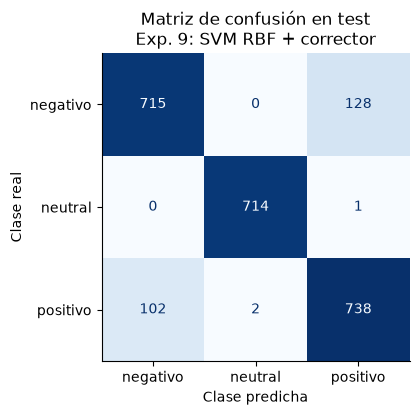

Negativo vs positivo en test: 0.862


In [13]:
metricas_e9 = evaluar_en_test(modelo_e9, f"Exp. 9: {elegido}")
np_test = (y_test != "neutral").to_numpy()
print(f"Negativo vs positivo en test: {(metricas_e9['pred'][np_test] == y_test.to_numpy()[np_test]).mean():.3f}")

### 2.7 Prueba de robustez en test

In [14]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 9", "escenario": e, "accuracy": accuracy_score(y_test, modelo_e9.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 7,Exp. 8,Exp. 9
escenario,,,
Original,0.9046,0.9096,0.9029
Oraciones desordenadas,0.7458,0.7621,0.7500
Última oración al inicio,0.6008,0.6467,0.6021


### 2.8 Registro y envío

In [15]:
from types import SimpleNamespace

resultados.append({
    "experimento": 9,
    "descripcion": f"Dos niveles con corrección de tipeo: {elegido}",
    "acc_cv": round(acc_final.mean(), 4),
    "std_cv": round(acc_final.std(), 4),
    "acc_test": round(metricas_e9["acc_test"], 4),
    "envio": "submission_09.csv",
    "kaggle_publico": None,
})
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,5,Un nivel: detector de opinión (sin conector) + TF-IDF por partes + LinearSVC,NaN,NaN,0.9022,0.0080,NaN,0.9021,NaN,submission_05.csv,NaN
2,7,Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1),NaN,NaN,0.9071,0.0091,NaN,0.9046,NaN,submission_07.csv,0.91
3,8,"Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",NaN,NaN,0.9048,0.0083,NaN,0.9096,NaN,submission_08.csv,NaN
4,9,Dos niveles con corrección de tipeo: SVM RBF + corrector,NaN,NaN,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,NaN


In [16]:
envio_e9 = generar_envio(SimpleNamespace(best_estimator_=modelo_e9), numero=9)

Envío guardado en envios/submission_09.csv y modelo en modelos/modelo_09.joblib
Distribución de predicciones en eval (%):
answer
negativo    36.9
neutral     27.6
positivo    35.5


### 2.9 Análisis del experimento 9

**Resultados:** accuracy de CV = **0,9065 ± 0,0086** (SVM RBF + corrector) y accuracy en test = **0,9029**.

| | Exp. 7 | Exp. 8 | Exp. 9 |
|---|---|---|---|
| Combinador | SVM RBF | LR + interacciones | SVM RBF + corrector |
| Accuracy CV | **0,9071** | 0,9048 | 0,9065 |
| Accuracy test | 0,9046 | **0,9096** | 0,9029 |
| Kaggle público | 0,91 | algo menos de 0,91 | **0,91555** |

1. **La corrección de tipeo no mejora el modelo final:** la diferencia con el experimento 7 (−0,06 en CV, −0,17 en
   test) está dentro del ruido. Solo aporta en el modelo de un nivel (+0,13).
2. **Confirma la meseta:** desde el experimento 6, todas las ideas probadas (combinadores, modelos base, interacciones,
   preprocesamiento) quedan entre 0,904 y 0,908 de CV. Las diferencias entre ellas son menores que la variación entre
   folds (≈ 0,008) y que el error estándar del leaderboard público.
3. **El techo estimado (≈ 0,937) no es alcanzable en la práctica con las técnicas de la Parte 1:** los ≈ 3 puntos
   restantes corresponden a errores dispersos (polaridades mal leídas, conectores ambiguos, oraciones descriptivas mal
   detectadas) sin un patrón dominante que una representación de bolsa de palabras o n-gramas pueda capturar.
   Aprovechar ese margen requeriría modelos que entiendan el texto en secuencia, que es el objetivo de la Parte 2.

**Decisión:** no se adopta el corrector en el modelo final; el mejor modelo sigue siendo el del **experimento 7**
(mejor score público, 0,91) o, como alternativa equivalente más fácil de sustentar, el del **experimento 8**. Se cierra
la fase de experimentación de la Parte 1.

### 2.10 Resultado en Kaggle y decisión final

`submission_09.csv` obtuvo **0,91555** en el leaderboard público, el mejor score del grupo (experimento 7: 0,91; experimento 8: algo menos de 0,91).

En la validación interna los experimentos 7, 8 y 9 están empatados (CV 0,9048–0,9071), así que la diferencia en el leaderboard público probablemente se deba en parte al ruido de evaluar con una parte de las 3.000 reseñas de eval. Aun así, el enunciado pide entregar el modelo del **envío con mejor resultado en la tabla pública**, por lo que **el modelo final de la Parte 1 es el del experimento 9** (`modelos/modelo_09.joblib`).

Para el ranking privado se recomienda marcar en Kaggle como envíos finales `submission_09` y, como cobertura, `submission_07` u `submission_08` (equivalentes en validación).